# 25 - Initial conditions & structure decide the transient: suppression vs. enablement

**Where we are.** Experiment 1 (notebook 22) settled the ontology and we accept it: the model is
**monostable**. There is one underlying baseline truth, so a community can never end up bistable *by
convergence* -- every population eventually relaxes to the truth. Chasing a second attractor is a dead
end, and so is the **forgetting** mechanism that was introduced to make the bistability test well-posed
(now removed from `src/`).

**The science left on the table is the transient.** Given that the asymptotic answer is always "the
truth," what do the **initial parameters and the network structure** decide about *how long* a wrong
paradigm holds, and *whether a challenger gets room to grow*? We contrast two configurations of the
**same agents** and the **same truth**:

| | **Model A -- suppression** | **Model B -- enablement by a split** |
|---|---|---|
| structure | dense, homogeneous (Watts-Strogatz) | clustered communities (SBM), bridged late |
| challenger | *scattered* through the field | *clustered* in its own community |
| incumbent | strong prior precision (`prec_scale`) | same |
| self-seal | mainstream stops running the refuting experiment (`experiment_bias=1`) | same |
| prediction | challenger diluted/absorbed -> long hold | protected incubation -> challenger seeds -> converges |

**The mechanism that makes structure matter.** With `precision_mode="heuristic"` and
`experiment_bias=1`, an agent that *holds phlogiston* self-censors the gravimetric (refuting)
experiment, while an agent that *holds oxygen* (the challenger) keeps running it. So the mainstream
goes blind to its own refuting evidence and the **only** route to truth is *social*: a trusted peer
who has actually looked. That is exactly when topology decides the outcome -- a scattered challenger is
out-voted by high-precision incumbents before it transmits; a clustered one incubates safely, then
bridges. (`core_governance` -- the paradigm-wide silencing of notebook 22 -- is left at 0 here, so the
self-seal is the *per-agent* held-paradigm gate, not a global mute that would stall everyone.)

**Primary order parameter:** the **suppression / convergence time** -- `time_to_half` (first crossing
of m=1/2) and `settling_time` (first entry into a stable band around the asymptote), read off the
population trajectory m(t). We run to convergence and report it.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
sys.path.insert(0, str(ROOT if (ROOT / 'src').exists() else ROOT.parent))
import numpy as np, dataclasses
import matplotlib.pyplot as plt
import jax
from src.config import NetworkConfig
from src.structural.phlogiston import StructuralConfig
from src.structural.kernel import Network
from src.structural import observables as obs
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

# ---- shared agents & truth (identical across A and B) -----------------------
N           = 24            # population
N_CHAL      = 3             # challenger (oxygen, truth-tracking) minority
PREC        = 40.0          # incumbent prior-precision bias (the headline strength)
HORIZON     = 800           # long enough for BOTH models to converge at PREC (logged cap)
T_INCUBATE  = 60            # Model B: protected-incubation window before the bridge opens
INTER       = 0.3           # Model B: bridge density once it opens
INTRA       = 0.5           # within-community trust density (Model B)
MEAN_DEG    = 6             # Watts-Strogatz degree (Model A dense field)
TOL, KSET   = 0.05, 5       # settling-time band / consecutive-step requirement

def groups(prec=PREC, n_chal=N_CHAL):
    '''The SAME population for both models: a high-precision phlogiston mainstream
    plus a small oxygen (truth-tracking) challenger minority.'''
    return [{'count': N - n_chal, 'paradigm': 'phlogiston', 'stance': -1.0, 'prec_scale': prec},
            {'count': n_chal,      'paradigm': 'oxygen'}]

def cfg_dense(prec=PREC, n_steps=HORIZON, seed=0):
    '''Model A: dense homogeneous Watts-Strogatz field (challenger scattered).'''
    return StructuralConfig(
        n_agents=N, n_steps=n_steps, precision_mode='heuristic', experiment_bias=1.0,
        core_governance=0.0, t_shift=0, seed=seed,
        network=NetworkConfig(kind='watts_strogatz', mean_degree=MEAN_DEG))

def cfg_split(prec=PREC, n_steps=HORIZON, seed=0):
    '''Model B: planted-SBM communities, initially disconnected (inter_prob=0).'''
    return StructuralConfig(
        n_agents=N, n_steps=n_steps, precision_mode='heuristic', experiment_bias=1.0,
        core_governance=0.0, t_shift=0, seed=seed,
        network=NetworkConfig(kind='planted_sbm', intra_prob=INTRA, inter_prob=0.0))

def run_A(prec=PREC, n_steps=HORIZON, seed=0):
    g = groups(prec)
    m, _ = Network.init(cfg_dense(prec, n_steps, seed), jax.random.PRNGKey(seed), g).run_trace()
    return m

def run_B(prec=PREC, n_steps=HORIZON, seed=0, t_inc=T_INCUBATE, inter=INTER):
    g = groups(prec)
    m, _ = Network.init(cfg_split(prec, n_steps, seed), jax.random.PRNGKey(seed), g
                        ).run_bridge(t_inc, inter, g)
    return m

print('smoke:',
      'A half =', obs.time_to_half(run_A()),
      '| B half =', obs.time_to_half(run_B()))

smoke: A half = 323 | B half = 217


## 1. Head-to-head: the same agents, the same truth, two structures

Both runs start from the identical population (a strong phlogiston mainstream + 3 oxygen challengers)
under the identical (stationary oxygen) truth. The **only** difference is the wiring: Model A connects
the challenger into a dense homogeneous field from step 0; Model B keeps it in its own community until
the bridge opens at `T_INCUBATE`.

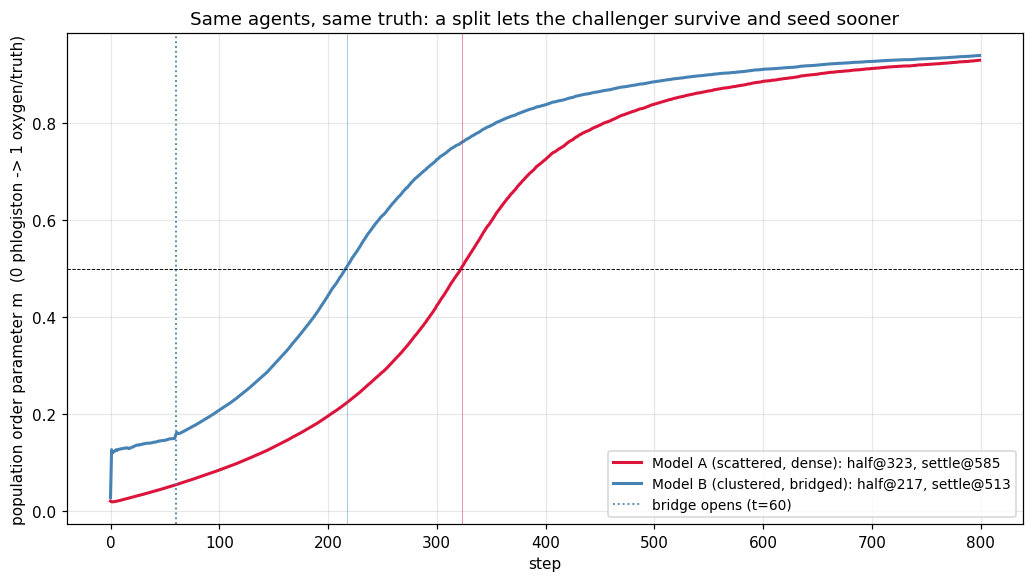

Model A: final m=0.931   time_to_half=323   settling_time=585
Model B: final m=0.940   time_to_half=217   settling_time=513
Both climb toward the truth (monostable). The wrong paradigm is held LONGER when the
challenger is scattered into the dense incumbent field than when a split protects it.


In [2]:
mA = run_A(); mB = run_B()
tA, tB = obs.time_to_half(mA), obs.time_to_half(mB)
sA, sB = obs.settling_time(mA, tol=TOL, k=KSET), obs.settling_time(mB, tol=TOL, k=KSET)

fig, ax = plt.subplots(figsize=(9.5, 5.4))
ax.plot(mA, color='crimson', lw=2, label=f'Model A (scattered, dense): half@{tA}, settle@{sA}')
ax.plot(mB, color='steelblue', lw=2, label=f'Model B (clustered, bridged): half@{tB}, settle@{sB}')
ax.axvline(T_INCUBATE, color='steelblue', ls=':', lw=1.2, label=f'bridge opens (t={T_INCUBATE})')
ax.axhline(0.5, color='k', lw=.6, ls='--')
for t, c in [(tA, 'crimson'), (tB, 'steelblue')]:
    if t < len(mA): ax.axvline(t, color=c, ls='-', lw=.6, alpha=.5)
ax.set_xlabel('step'); ax.set_ylabel('population order parameter m  (0 phlogiston -> 1 oxygen/truth)')
ax.set_title('Same agents, same truth: a split lets the challenger survive and seed sooner')
ax.legend(loc='lower right', fontsize=9); plt.tight_layout(); plt.show()

print(f'Model A: final m={mA[-1]:.3f}   time_to_half={tA}   settling_time={sA}')
print(f'Model B: final m={mB[-1]:.3f}   time_to_half={tB}   settling_time={sB}')
print('Both climb toward the truth (monostable). The wrong paradigm is held LONGER when the')
print('challenger is scattered into the dense incumbent field than when a split protects it.')

## 2. Why -- the per-community mechanism

The population curve hides the mechanism; the per-community trajectories (`run_bridge_index` /
`run_trace_index`) reveal it. We track the mean oxygen-index of the **mainstream** and the
**challenger** separately.

- **Model B (split):** during incubation the clustered challenger -- talking only to itself, and still
  running the refuting experiment -- drives its conviction to ~1, while the self-sealed mainstream sits
  flat (it has gone blind to its own refuting evidence). When the bridge opens, the now-confident
  challenger pulls the mainstream over. The challenger *dips* at the moment of contact (it pays a price
  for fusing with a phlogiston majority) but recovers as the mainstream converts.
- **Model A (scattered):** the challenger is wired into high-precision incumbents from step 0. Its
  conviction is dragged down by precision-weighted fusion faster than its own evidence can lift it --
  it is partially **absorbed**, so it never builds the conviction needed to seed quickly.

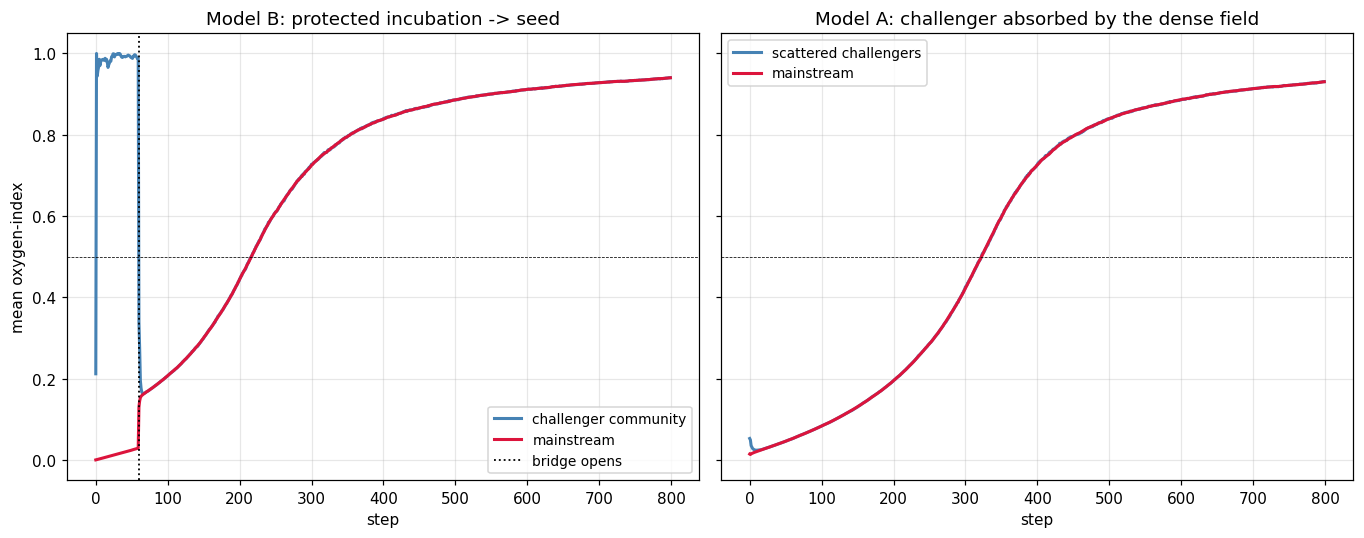

Model B challenger conviction at bridge (t=60): 0.99  (built up in isolation)
Model A challenger conviction at the same step:        0.05  (dragged down by precision-weighted fusion)


In [3]:
g = groups()
# Model B: per-agent index through the bridge.
oxB = Network.init(cfg_split(seed=0), jax.random.PRNGKey(0), g).run_bridge_index(T_INCUBATE, INTER, g)
mainB, chalB = oxB[:, :N - N_CHAL].mean(1), oxB[:, N - N_CHAL:].mean(1)
# Model A: per-agent index (static dense wiring).
from src.structural import step as _S
stateA = _S.init_state(cfg_dense(seed=0), jax.random.PRNGKey(0), g)
oxA = np.asarray(_S.run_trace_index(cfg_dense(seed=0), stateA))
mainA, chalA = oxA[:, :N - N_CHAL].mean(1), oxA[:, N - N_CHAL:].mean(1)

fig, (axB, axA) = plt.subplots(1, 2, figsize=(12.5, 5.0), sharey=True)
axB.plot(chalB, color='steelblue', lw=2, label='challenger community')
axB.plot(mainB, color='crimson', lw=2, label='mainstream')
axB.axvline(T_INCUBATE, color='k', ls=':', lw=1.2, label='bridge opens')
axB.set_title('Model B: protected incubation -> seed'); axB.set_xlabel('step')
axB.set_ylabel('mean oxygen-index'); axB.legend(fontsize=9); axB.axhline(0.5, color='k', lw=.5, ls='--')

axA.plot(chalA, color='steelblue', lw=2, label='scattered challengers')
axA.plot(mainA, color='crimson', lw=2, label='mainstream')
axA.set_title('Model A: challenger absorbed by the dense field'); axA.set_xlabel('step')
axA.legend(fontsize=9); axA.axhline(0.5, color='k', lw=.5, ls='--')
plt.tight_layout(); plt.show()

print(f'Model B challenger conviction at bridge (t={T_INCUBATE}): {chalB[T_INCUBATE-1]:.2f}'
      f'  (built up in isolation)')
print(f'Model A challenger conviction at the same step:        {chalA[T_INCUBATE-1]:.2f}'
      f'  (dragged down by precision-weighted fusion)')

## 3. Incumbent bias sweep: when does a split actually help?

The contrast above is at a strong incumbent (`prec_scale=40`). Honesty demands the whole curve: at
*weak* incumbent precision a scattered-but-connected challenger transmits **immediately**, so Model A
is actually the faster one (a split only delays contact). A split pays off **once the incumbent is
strong enough to absorb a scattered challenger**. We sweep `prec_scale` and plot the suppression time
(`time_to_half`) for both models, median +- IQR over seeds.

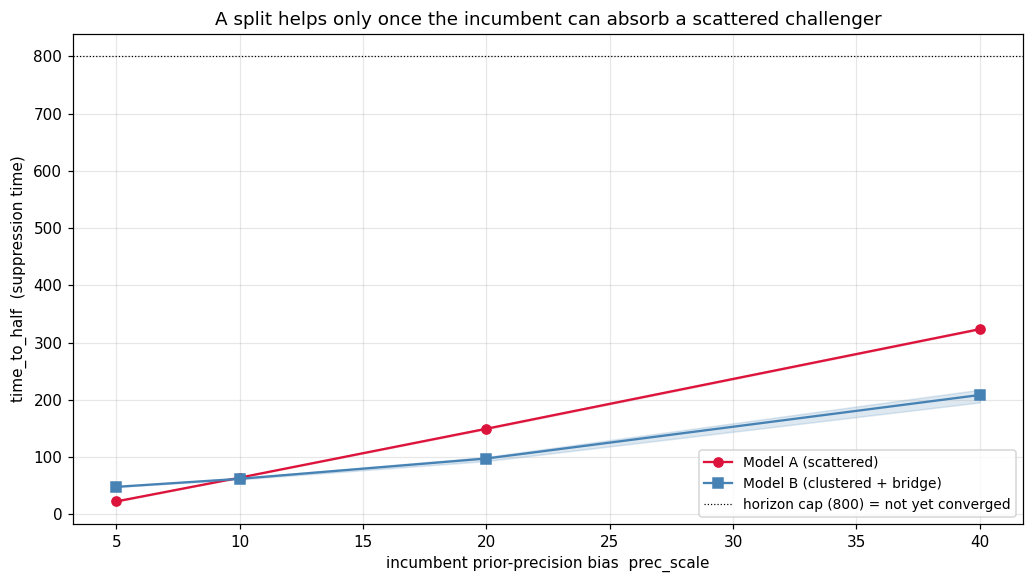

prec_scale |  A half (med) |  B half (med)  | split advantage (A-B)
       5   |        22     |        48      |      -26
      10   |        64     |        62      |       +2
      20   |       150     |        98      |      +52
      40   |       324     |       208      |     +115


In [4]:
PRECS = [5.0, 10.0, 20.0, 40.0]
SEEDS = range(4)                       # logged cap: 4 seeds/cell (topology + noise)
def band(fn, **kw):
    v = np.array([fn(seed=s, **kw) for s in SEEDS], dtype=float)
    return np.median(v), np.percentile(v, 25), np.percentile(v, 75)

halfA = np.array([band(lambda seed, p=p: obs.time_to_half(run_A(prec=p, seed=seed))) for p in PRECS])
halfB = np.array([band(lambda seed, p=p: obs.time_to_half(run_B(prec=p, seed=seed))) for p in PRECS])

fig, ax = plt.subplots(figsize=(9.5, 5.4))
ax.plot(PRECS, halfA[:, 0], 'o-', color='crimson', label='Model A (scattered)')
ax.fill_between(PRECS, halfA[:, 1], halfA[:, 2], color='crimson', alpha=.18)
ax.plot(PRECS, halfB[:, 0], 's-', color='steelblue', label='Model B (clustered + bridge)')
ax.fill_between(PRECS, halfB[:, 1], halfB[:, 2], color='steelblue', alpha=.18)
ax.axhline(HORIZON, color='k', ls=':', lw=.8, label=f'horizon cap ({HORIZON}) = not yet converged')
ax.set_xlabel('incumbent prior-precision bias  prec_scale'); ax.set_ylabel('time_to_half  (suppression time)')
ax.set_title('A split helps only once the incumbent can absorb a scattered challenger')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

print('prec_scale |  A half (med) |  B half (med)  | split advantage (A-B)')
for p, a, b in zip(PRECS, halfA[:, 0], halfB[:, 0]):
    print(f'   {p:5.0f}   |    {a:6.0f}     |    {b:6.0f}      |   {a-b:+6.0f}')

## 4. Model B's knobs: bridge timing and width

Within the split regime, two design knobs govern the rescue: **how long** the challenger incubates
before contact (`t_incubate`) and **how wide** the bridge is when it opens (`inter_prob`). Too short an
incubation and the challenger hasn't built conviction; too wide a bridge and contact floods the
challenger before it is ready. We sweep each at the headline incumbent strength.

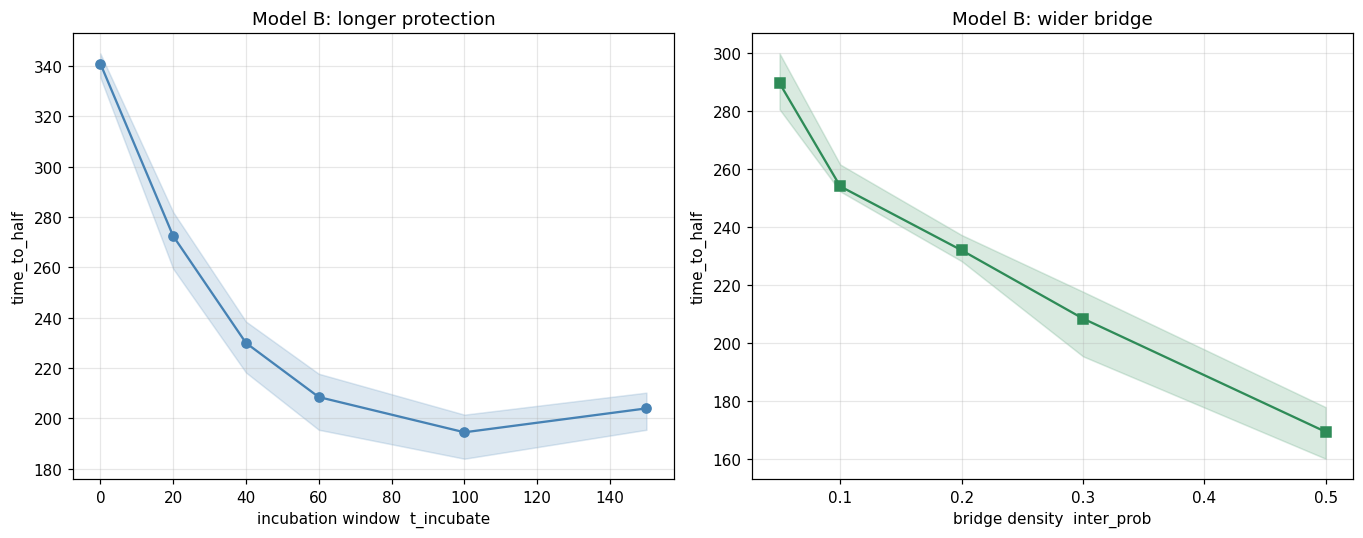

t_incubate sweep  time_to_half (median): {0: np.int64(341), 20: np.int64(272), 40: np.int64(230), 60: np.int64(208), 100: np.int64(194), 150: np.int64(204)}
inter_prob sweep  time_to_half (median): {0.05: np.int64(290), 0.1: np.int64(254), 0.2: np.int64(232), 0.3: np.int64(208), 0.5: np.int64(170)}


In [5]:
# (a) incubation window
T_INCS = [0, 20, 40, 60, 100, 150]
hb_t = np.array([band(lambda seed, ti=ti: obs.time_to_half(run_B(seed=seed, t_inc=ti))) for ti in T_INCS])
# (b) bridge width
INTERS = [0.05, 0.1, 0.2, 0.3, 0.5]
hb_w = np.array([band(lambda seed, w=w: obs.time_to_half(run_B(seed=seed, inter=w))) for w in INTERS])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5.0))
ax1.plot(T_INCS, hb_t[:, 0], 'o-', color='steelblue'); ax1.fill_between(T_INCS, hb_t[:, 1], hb_t[:, 2], color='steelblue', alpha=.18)
ax1.set_xlabel('incubation window  t_incubate'); ax1.set_ylabel('time_to_half'); ax1.set_title('Model B: longer protection')
ax2.plot(INTERS, hb_w[:, 0], 's-', color='seagreen'); ax2.fill_between(INTERS, hb_w[:, 1], hb_w[:, 2], color='seagreen', alpha=.18)
ax2.set_xlabel('bridge density  inter_prob'); ax2.set_title('Model B: wider bridge'); ax2.set_ylabel('time_to_half')
plt.tight_layout(); plt.show()
print('t_incubate sweep  time_to_half (median):', dict(zip(T_INCS, hb_t[:, 0].round().astype(int))))
print('inter_prob sweep  time_to_half (median):', dict(zip(INTERS, hb_w[:, 0].round().astype(int))))

## 5. Monostability check + verdict

The headline difference is a **transient**, not a second basin: given a long enough horizon, the
suppressed Model A *also* reaches the truth. We confirm it with an extended run, then state the
verdict and log every cap.

In [6]:
mA_long = run_A(n_steps=1500, seed=0)
print('Monostability check -- Model A at a 1500-step horizon:')
print(f'  final m = {mA_long[-1]:.3f}   time_to_half = {obs.time_to_half(mA_long)}'
      f'   settling_time = {obs.settling_time(mA_long, tol=TOL, k=KSET)}')
print('  => the dense, self-sealed, strongly-biased field DOES converge to the truth -- just slowly.')
print('     The wrong paradigm is HELD for a long transient (Planck / Azoulay "one funeral at a time"),')
print('     it is not a permanent second attractor. Structure and bias buy the incumbent TIME; a split')
print('     buys the challenger time.')
print()
print('Verdict')
print('-------')
print('* Monostable premise holds: both Model A and Model B relax to m -> 1 (the truth).')
print('* The science is the transient: SUPPRESSION TIME, not final state.')
print('* Strong incumbent + scattered challenger (Model A) => long suppression (challenger absorbed).')
print('* Same agents, clustered + bridged (Model B) => protected incubation => the challenger survives')
print('  and seeds the majority sooner.')
print('* HONEST caveat (Section 3): a split only helps once prec_scale is large enough to absorb a')
print('  scattered challenger; at weak incumbents an immediately-connected challenger is faster.')
print()
print('Logged caps (no silent truncation):')
print(f'  - seeds per swept cell: 4 (topology seed + observation noise)')
print(f'  - horizon: {HORIZON} steps (head-to-head/sweeps); 1500 for the monostability check')
print(f'  - population N={N}, challenger minority={N_CHAL}, d=10 phlogiston net')
print(f'  - precision_mode="heuristic", experiment_bias=1.0, core_governance=0.0 (per-agent self-seal)')
print(f'  - topology FIXED per model (A: Watts-Strogatz deg {MEAN_DEG}; B: planted-SBM intra={INTRA});')
print(f'    placement/topology family not swept here (left for the committed-minority study, nb24)')

Monostability check -- Model A at a 1500-step horizon:
  final m = 0.972   time_to_half = 323   settling_time = 755
  => the dense, self-sealed, strongly-biased field DOES converge to the truth -- just slowly.
     The wrong paradigm is HELD for a long transient (Planck / Azoulay "one funeral at a time"),
     it is not a permanent second attractor. Structure and bias buy the incumbent TIME; a split
     buys the challenger time.

Verdict
-------
* Monostable premise holds: both Model A and Model B relax to m -> 1 (the truth).
* The science is the transient: SUPPRESSION TIME, not final state.
* Strong incumbent + scattered challenger (Model A) => long suppression (challenger absorbed).
* Same agents, clustered + bridged (Model B) => protected incubation => the challenger survives
  and seeds the majority sooner.
* HONEST caveat (Section 3): a split only helps once prec_scale is large enough to absorb a
  scattered challenger; at weak incumbents an immediately-connected challenger is fa